## Import - This notebook is for data analysis and visulization

In [1]:
import numpy as np
import matplotlib.pyplot as plt
pr = "5"
netname = "5x5net"
link_num = 40

In [2]:
 # path of results files
coverTable_benchmark = '../result/{}/PR{} TestingNew/pr{}_cover_benchmark.npy'.format(netname, pr, pr)
# coverTable_benchmark = '../result/cover_0_step20.npy'
coverTable1 = '../result/{}/PR{} TestingNew/pr{}_cover_0_step20.npy'.format(netname, pr, pr)
coverTable2 = '../result/{}/PR{} TestingNew/pr{}_cover_1_step20.npy'.format(netname, pr, pr)
coverTable3 = '../result/{}/PR{} TestingNew/pr{}_cover_2_step20.npy'.format(netname, pr, pr)
# coverTable4 = '../result/PR{} Testing/pr{}_cover_100_step20_deroute4.npy'.format(pr, pr)

# coverTable3 = '../result/{}/PR{} TestingNew/pr{}_cover_500_step20.npy'.format(netname, pr, pr)
coverTable4 = '../result/{}/PR{} TestingNew/pr{}_cover_5_step20.npy'.format(netname, pr, pr)
coverTable5 = '../result/{}/PR{} TestingNew/pr{}_cover_10_step20.npy'.format(netname, pr, pr)
# coverTable6 = '../result/{}/PR{} TestingNew/pr{}_cover_100000_step20.npy'.format(netname, 2, 2)
lb_list = ['benchmark', '1:0', '1:500', '1:500', '1:5000', '1:10000', '1:10000']
# lb_list = ['benchmark', '1:0', '1:300(20)', '1:500(40)']

In [3]:
# # alternative paths files 
# coverTable_benchmark = '../result/PR{} TestingNew/pr{}_cover_benchmark.npy'.format(pr, pr)
# coverTable1 = '../result/PR{} TestingNew/pr{}_cover_0_step20.npy'.format(pr, pr)
# coverTable2 = '../result/PR{} TestingNew/pr{}_cover_100_step20.npy'.format(pr, pr)
# coverTable3 = '../result/PR{} TestingNew/pr{}_cover_300_step20.npy'.format(pr, pr)
# coverTable4 = '../result/PR{} TestingNew/pr{}_cover_500_step20.npy'.format(pr, pr)
# coverTable5 = '../result/PR{} TestingNew/pr{}_cover_1000_step20.npy'.format(pr, pr)
# coverTable6 = '../result/PR{} TestingNew/pr{}_cover_2000_step20.npy'.format(pr, pr)
# lb_list = ['benchmark', '1:0', '1:100', '1:300', '1:500', '1:1000', '1:2000']
# # lb_list = ['benchmark', '1:0', '1:300(20)', '1:500(40)']

In [4]:
# load cover table
cover_ben = np.load(coverTable_benchmark)
cover_1 = np.load(coverTable1)
cover_2 = np.load(coverTable2)
cover_3 = np.load(coverTable3)
cover_4 = np.load(coverTable4)
cover_5 = np.load(coverTable5)
# cover_6 = np.load(coverTable6)

In [5]:
cover_ben.shape

(80, 1800, 1000)

### 1. Link Cover Rate

In [6]:
# draw space time table
def drawTimeSpace(table, link_num=40):
    idx  = np.arange(0, 1800, 1)
    linkTime_table = np.sum(table, axis=2)
#     print(linkTime_table.shape)
    del table
    linkTime_cover = np.where(linkTime_table[:, idx]>0, 1, 0)
#     linkTime_cover2 = np.where
    figs,axs = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(18, 1))
    axs[0].imshow(linkTime_table[:, idx], cmap='viridis', interpolation='none')
    axs[1].imshow(linkTime_cover, cmap='viridis', interpolation='none')
#     print(linkTime_cover.shape)
#     tx = [i for i in range (linkTime_cover.shape[1])]
#     axs[2].plot(tx, np.sum(linkTime_cover, axis=0)/80)
#     axs[2].set_ylim(0.2, 0.8)
    print('cover rate is:', np.sum(linkTime_cover)/linkTime_cover.size)

    return linkTime_cover, np.sum(linkTime_cover, axis=0)/(2*link_num), round(np.sum(linkTime_cover)/linkTime_cover.size, 2)

cover rate is: 0.470125


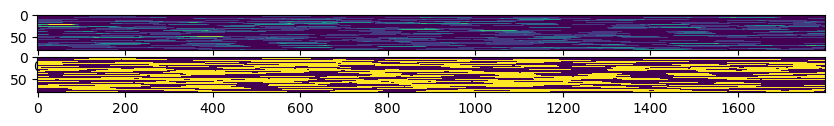

In [7]:
cover_rates = [i for i in range(6)]
LT_ben, coverTime_ben, cover_rates[0] = drawTimeSpace(cover_ben, link_num)

cover rate is: 0.5504166666666667


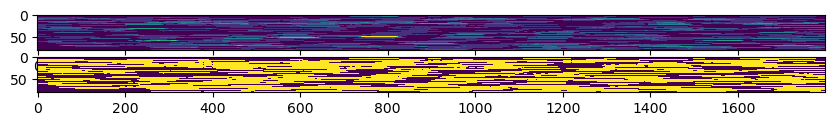

In [8]:
LT_1, coverTime_1, cover_rates[1] = drawTimeSpace(cover_1, link_num)

cover rate is: 0.5643263888888889


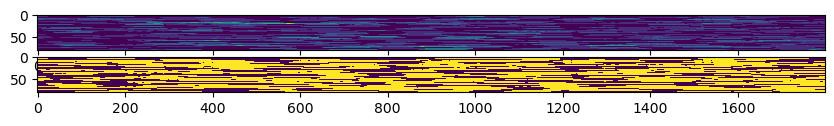

In [9]:
LT_2, coverTime_2, cover_rates[2] = drawTimeSpace(cover_2, link_num)

cover rate is: 0.5949097222222223


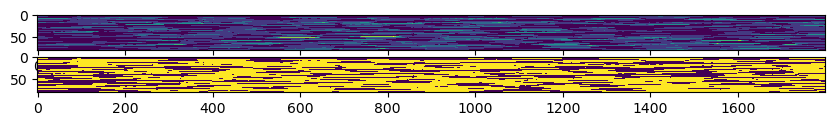

In [10]:
LT_3, coverTime_3, cover_rates[3] = drawTimeSpace(cover_3, link_num)

cover rate is: 0.6392083333333334


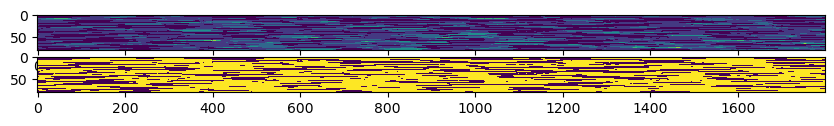

In [11]:
LT_4, coverTime_4, cover_rates[4] = drawTimeSpace(cover_4, link_num)

cover rate is: 0.6719097222222222


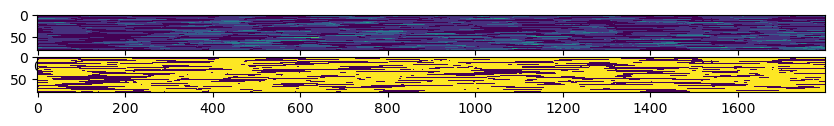

In [12]:
LT_5, coverTime_5, cover_rates[5] = drawTimeSpace(cover_5, link_num)

In [13]:
# LT_6, coverTime_6 = drawTimeSpace(cover_6, link_num)

(0.3, 0.8)

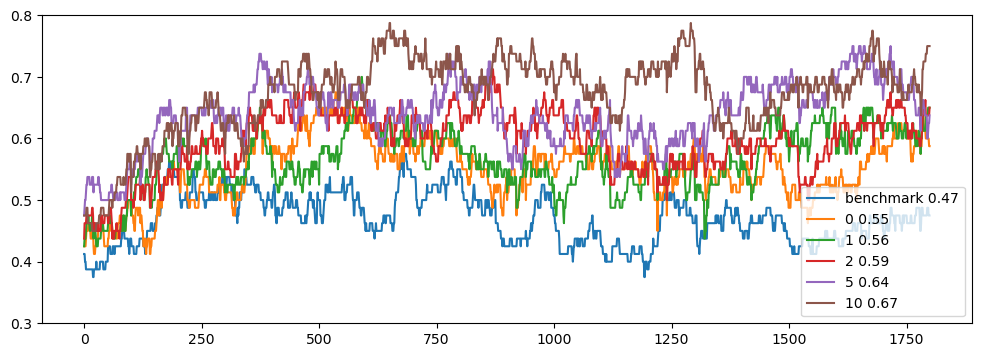

In [33]:
# plot coverage over time 
tx = [i for i in range (coverTime_ben.shape[0])]
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(tx, coverTime_ben, label = "benchmark {}".format(cover_rates[0]))
ax.plot(tx, coverTime_1, label = "0 {}".format(cover_rates[1]))
ax.plot(tx, coverTime_2, label = "1 {}".format(cover_rates[2]))
ax.plot(tx, coverTime_3, label = "2 {}".format(cover_rates[3]))
ax.plot(tx, coverTime_4, label = "5 {}".format(cover_rates[4]))
ax.plot(tx, coverTime_5, label = "10 {}".format(cover_rates[5]))
ax.legend(loc = 4)
ax.set_ylim(0.3, 0.8)

### 2. Vehicle Travel Time

In [49]:
# cover_table = [link, time, veh]
def getTravelTime(table, max_veh_num):
    idx  = np.arange(0, 1800, 1)
    veh_time_table = np.where(np.sum(table, axis=0)[:, :max_veh_num]>0, 1, 0) # [time, veh]
    
#     idx  = np.arange(0, 3600, 1)
#     veh_time_table =np.sum(table, axis=0)>0  
    print(veh_time_table.shape)
    travel_table = np.sum(veh_time_table, axis=0)
    return travel_table


In [54]:
max_veh = 140
# getTravelTime(cover_ben, max_veh),
travelTime_list = [getTravelTime(cover_ben, max_veh),
                   getTravelTime(cover_1, max_veh), 
                   getTravelTime(cover_2, max_veh),
                   getTravelTime(cover_3, max_veh),
                   getTravelTime(cover_4, max_veh),
                   getTravelTime(cover_5, max_veh)]
#                    getTravelTime(cover_6, max_veh),]
veh_list = ['{}'.format(str(i+1)) for i in range(20, 20+max_veh)]
total_width, n = 1, len(travelTime_list)
width = total_width/n
x = np.arange(len(veh_list))
# plt.figure(figsize=(18, 9), dpi=80)

# for k in range(len(travelTime_list)):
#     xx = x + np.ones(x.shape)*k*width
#     plt.bar(xx, travelTime_list[k], width=width, label = str(k), tick_label = veh_list)
# plt.legend(lb_list, fontsize=15)
# plt.show()

(1800, 140)
(1800, 140)
(1800, 140)
(1800, 140)
(1800, 140)
(1800, 140)


In [55]:
len(travelTime_list[2])

140

[327.49285714 135.97857143 135.62142857 143.66428571 150.55
 153.77142857] [0.470125   0.55041667 0.56432639 0.59490972 0.63920833 0.67190972]


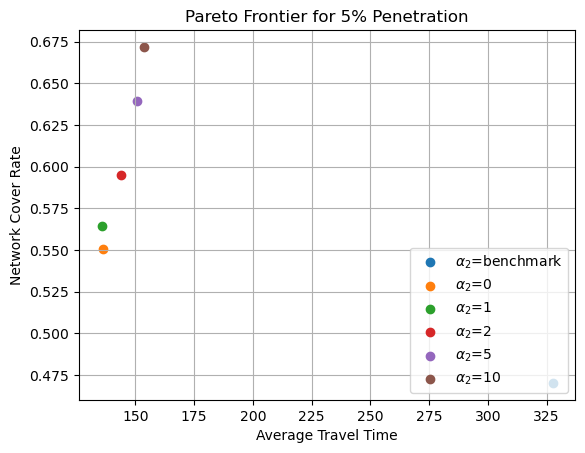

In [56]:
tt_mean = np.mean(np.array(travelTime_list),axis=1)  # travel time

# np.sum(LT_ben)/LT_ben.size,
cover_mean = np.array([np.sum(LT_ben)/LT_ben.size,
                       np.sum(LT_1)/LT_1.size,
                       np.sum(LT_2)/LT_2.size, 
                       np.sum(LT_3)/LT_3.size,
                       np.sum(LT_4)/LT_4.size,
                       np.sum(LT_5)/LT_5.size])
#                        np.sum(LT_6)/LT_6.size])
alpha_list = ['benchmark',0, 1, 2, 5, 10]
# deroute_list = ['benchmark', '0+2', '100+2', '0+4', '100+4', '1000', '2000']
for i in range(tt_mean.shape[0]):
#     plt.scatter(tt_mean[i], cover_mean[i], label = str(deroute_list[i]))
    plt.scatter(tt_mean[i], cover_mean[i], label = '$\u03B1_{2}$'+"="+ str(alpha_list[i]))
plt.legend(loc=4)
plt.xlabel('Average Travel Time')
plt.ylabel('Network Cover Rate')
plt.title('Pareto Frontier for {}% Penetration'.format(pr))
plt.grid()
print(tt_mean, cover_mean)

In [19]:
### 3. Network Visulize

In [20]:
import networkx as nx
import sumolib

#### 3.1 load network

In [21]:
def getDis(crd1, crd2):
    return np.sqrt((crd1[0] - crd2[0]) ** 2 + (crd1[1] - crd2[1]) ** 2)

In [22]:
def netInit(X, Y, net_file='../sumo_cfg/toy_net/toy_net1.net.xml'):
    net = sumolib.net.readNet(net_file)
    G = nx.DiGraph()
    tmp_node = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
    pos = {}
    for x in range(X):
        for y in range(Y):
            node_idx = tmp_node[x]+tmp_node[y]
            pos[node_idx] = net.getNode(node_idx).getCoord()
            G.add_node(node_idx, color='red', pos=net.getNode(node_idx).getCoord())
    
    for x in range(X):
        for y in range(Y):
            if x + 1 < X and y + 1 < Y:
                current = tmp_node[x] + tmp_node[y]
                current_right = tmp_node[x] + tmp_node[y + 1]
                current_down = tmp_node[x + 1] + tmp_node[y]
                dis1 = getDis(net.getNode(current).getCoord(), net.getNode(current_right).getCoord())
                dis2 = getDis(net.getNode(current).getCoord(), net.getNode(current_down).getCoord())
                G.add_weighted_edges_from([(current, current_right, dis1),
                                           (current_right, current, dis1),
                                           (current, current_down, dis2),
                                           (current_down, current, dis2)])
    
            elif y + 1 == Y and x + 1 < X:
                current = tmp_node[x] + tmp_node[y]
                current_down = tmp_node[x + 1] + tmp_node[y]
                dis2 = getDis(net.getNode(current).getCoord(), net.getNode(current_down).getCoord())
                G.add_weighted_edges_from([(current, current_down, dis2), (current_down, current, dis2)])
            elif x + 1 == X and y + 1 < Y:
                current = tmp_node[x] + tmp_node[y]
                current_right = tmp_node[x] + tmp_node[y + 1]
                dis1 = getDis(net.getNode(current).getCoord(), net.getNode(current_right).getCoord())
                G.add_weighted_edges_from([(current, current_right, dis1), (current_right, current, dis1)])
            elif x == y == X-1:
                break
    return G, pos

In [23]:
G, pos = netInit(5,5)

(('AA', 'AB'), ('AA', 'BA'), ('AB', 'AA'), ('AB', 'AC'), ('AB', 'BB'), ('AC', 'AB'), ('AC', 'AD'), ('AC', 'BC'), ('AD', 'AC'), ('AD', 'AE'), ('AD', 'BD'), ('AE', 'AD'), ('AE', 'BE'), ('BA', 'AA'), ('BA', 'BB'), ('BA', 'CA'), ('BB', 'AB'), ('BB', 'BA'), ('BB', 'BC'), ('BB', 'CB'), ('BC', 'AC'), ('BC', 'BB'), ('BC', 'BD'), ('BC', 'CC'), ('BD', 'AD'), ('BD', 'BC'), ('BD', 'BE'), ('BD', 'CD'), ('BE', 'AE'), ('BE', 'BD'), ('BE', 'CE'), ('CA', 'BA'), ('CA', 'CB'), ('CA', 'DA'), ('CB', 'BB'), ('CB', 'CA'), ('CB', 'CC'), ('CB', 'DB'), ('CC', 'BC'), ('CC', 'CB'), ('CC', 'CD'), ('CC', 'DC'), ('CD', 'BD'), ('CD', 'CC'), ('CD', 'CE'), ('CD', 'DD'), ('CE', 'BE'), ('CE', 'CD'), ('CE', 'DE'), ('DA', 'CA'), ('DA', 'DB'), ('DA', 'EA'), ('DB', 'CB'), ('DB', 'DA'), ('DB', 'DC'), ('DB', 'EB'), ('DC', 'CC'), ('DC', 'DB'), ('DC', 'DD'), ('DC', 'EC'), ('DD', 'CD'), ('DD', 'DC'), ('DD', 'DE'), ('DD', 'ED'), ('DE', 'CE'), ('DE', 'DD'), ('DE', 'EE'), ('EA', 'DA'), ('EA', 'EB'), ('EB', 'DB'), ('EB', 'EA'), ('EB'

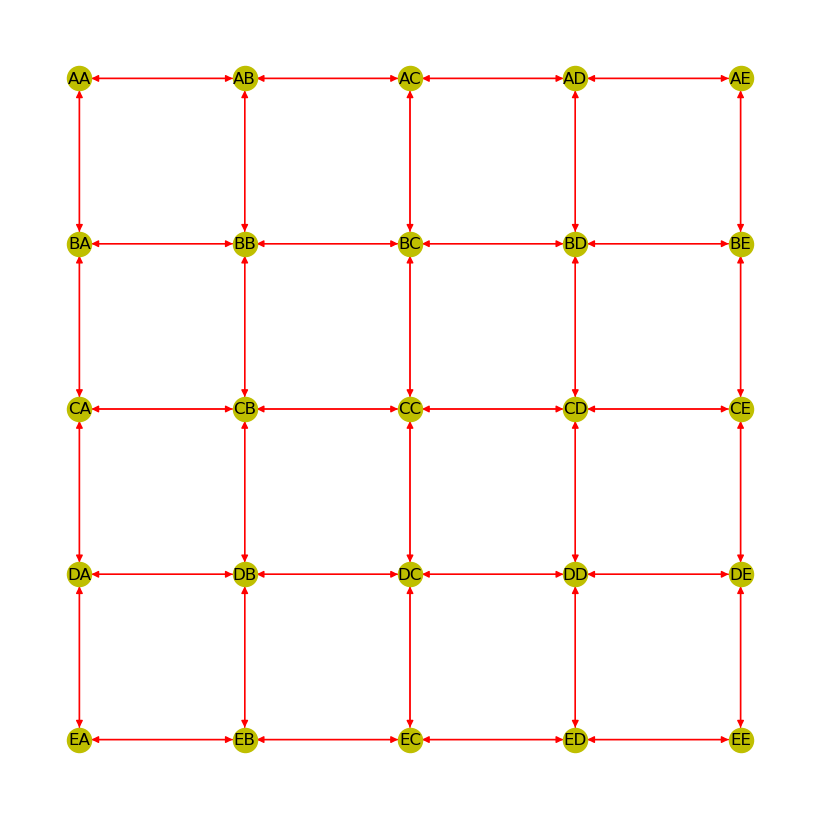

In [24]:
plt.figure(figsize=(8, 8))
edges,weights = zip(*nx.get_edge_attributes(G,'weight').items())
print(edges)

# pos = nx.layout(G)
# print(pos)
# print(edges)
# print(weights)

nx.draw(G, pos, with_labels = True, node_color='y',
        edgelist=edges, edge_color='r', 
        width=1, edge_cmap=plt.cm.Blues)
plt.show()

# nx.draw(H, pos, with_labels = True, node_color='y', 
#         edgelist=edges, edge_color=weights, 
#         width=weights, edge_cmap=plt.cm.Blues)



### 3.2 visulize cover&TT

In [25]:
import numpy as np
import sumolib
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap

def drawCoverNet(G, cover_table, net_file='../sumo_cfg/5x5net/5x5net.net.xml'):
    obs_table = np.where(np.sum(cover_table, axis=2) > 0, 1, 0)
    link_cover = np.sum(obs_table, axis=1) / obs_table.shape[1]
    net = sumolib.net.readNet(net_file)

    # Get node positions from SUMO net file
    pos = {}
    for node in net.getNodes():
        pos[node.getID()] = node.getCoord()

#     for i in range(link_cover.shape[0]):
    for i in range(80):
        if i < 40:
            edge_id = 'E' + str(i + 1)
        else:
            edge_id = '-E' + str(i - 39)

        nextNodeID = net.getEdge(edge_id).getToNode().getID()
        lastNodeID = net.getEdge(edge_id).getFromNode().getID()
        G[lastNodeID][nextNodeID]['weight'] = link_cover[i]

    plt.figure(figsize=(10, 8))
    edges, weights = zip(*nx.get_edge_attributes(G, 'weight').items())
    
    # Create a custom colormap for enhanced contrast
    colors = [(0, 1, 0), (1, 1, 0), (1, 0, 1)]  # Green -> Yellow -> Red
    cmap_name = 'custom_div_cmap'
    cmap = LinearSegmentedColormap.from_list(cmap_name, colors, N=100)
    
    norm = mcolors.Normalize(vmin=0, vmax=1)
    edge_colors = [cmap(norm(w)) for w in weights]

    for (src, dst, data), color in zip(G.edges(data=True), edge_colors):
        x0, y0 = pos[src]
        x1, y1 = pos[dst]
        rad = 0.1  # Radius of curvature
        arrowprops=dict(arrowstyle='-|>',
                        color=color,
                        lw=2,  # constant line width
                        connectionstyle=f"arc3,rad={rad}")
        plt.annotate("",
                     xy=(x1, y1),
                     xytext=(x0, y0),
                     arrowprops=arrowprops)

    # Adding colorbar to represent the weight
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    plt.colorbar(sm, label='Weight')

    nx.draw_networkx_nodes(G, pos, node_color='yellow')
    nx.draw_networkx_labels(G, pos)

    plt.axis('off')
    plt.show()


/tmp/ipykernel_86565/788917706.py:55: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  plt.colorbar(sm, label='Weight')


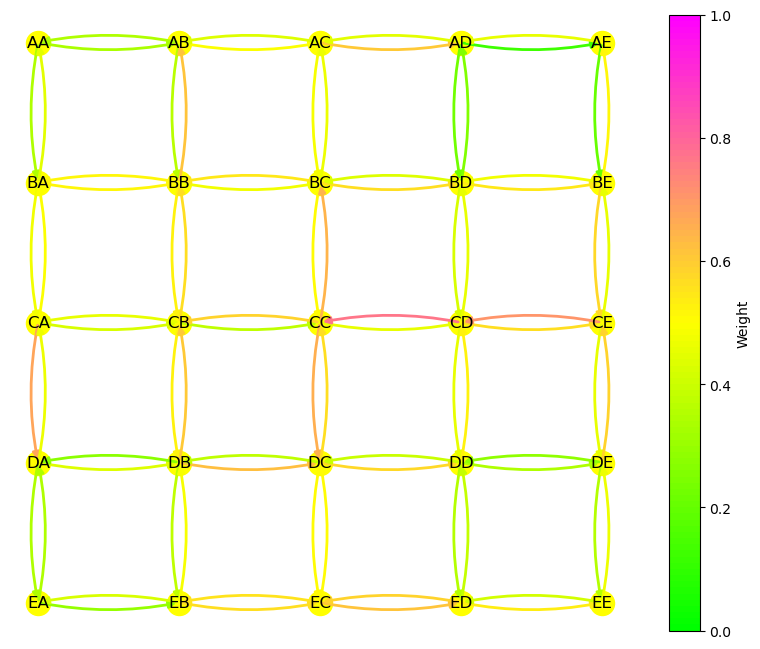

In [26]:
drawCoverNet(G, cover_ben)

/tmp/ipykernel_86565/788917706.py:55: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  plt.colorbar(sm, label='Weight')


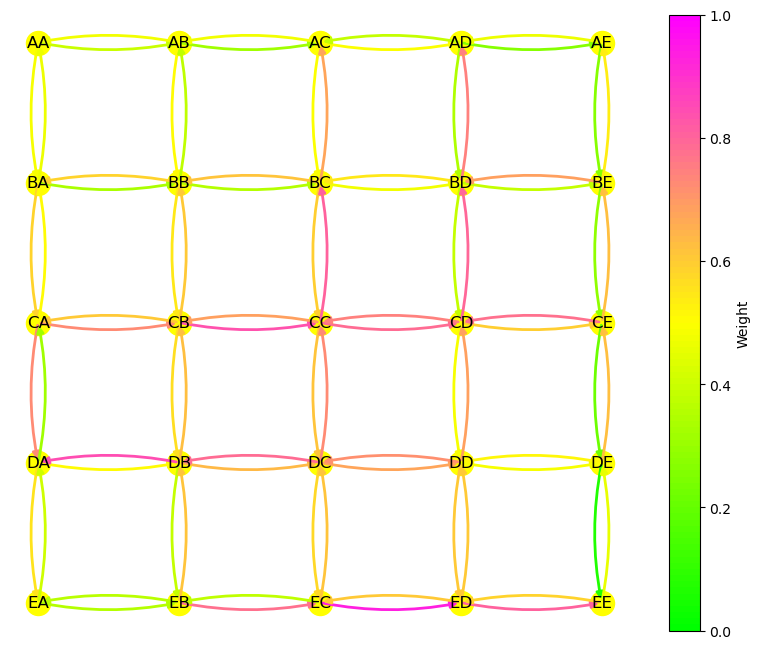

In [27]:
drawCoverNet(G, cover_1)

/tmp/ipykernel_86565/788917706.py:55: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  plt.colorbar(sm, label='Weight')


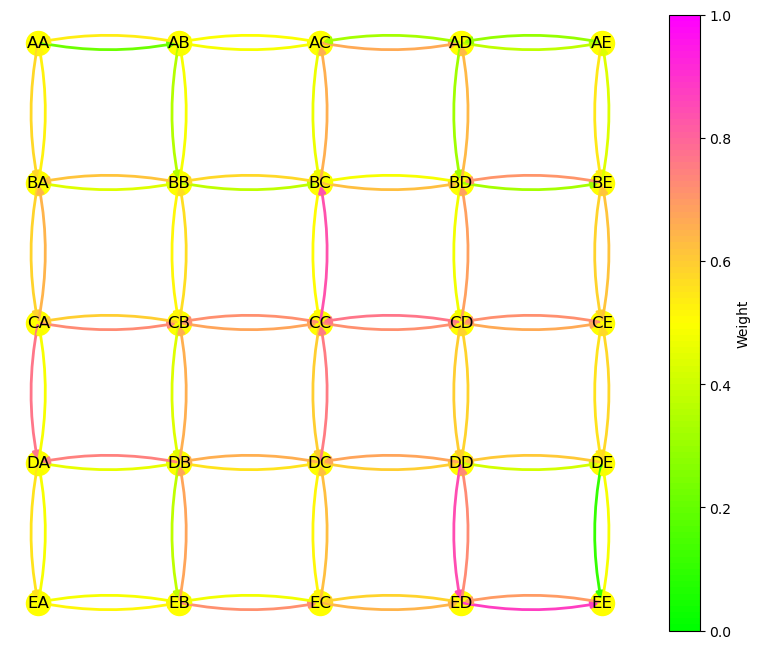

In [28]:
drawCoverNet(G, cover_2)

/tmp/ipykernel_86565/788917706.py:55: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  plt.colorbar(sm, label='Weight')


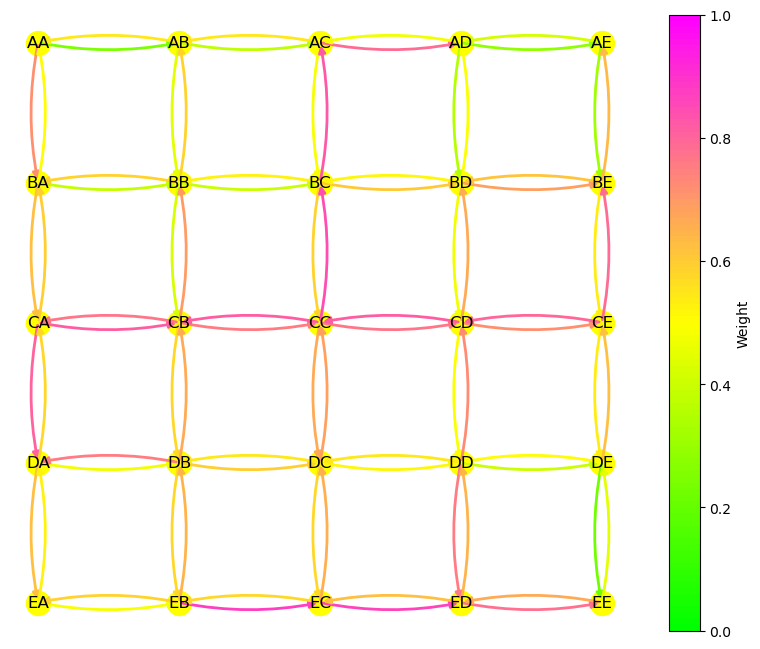

In [29]:
drawCoverNet(G, cover_3)

/tmp/ipykernel_86565/788917706.py:55: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  plt.colorbar(sm, label='Weight')


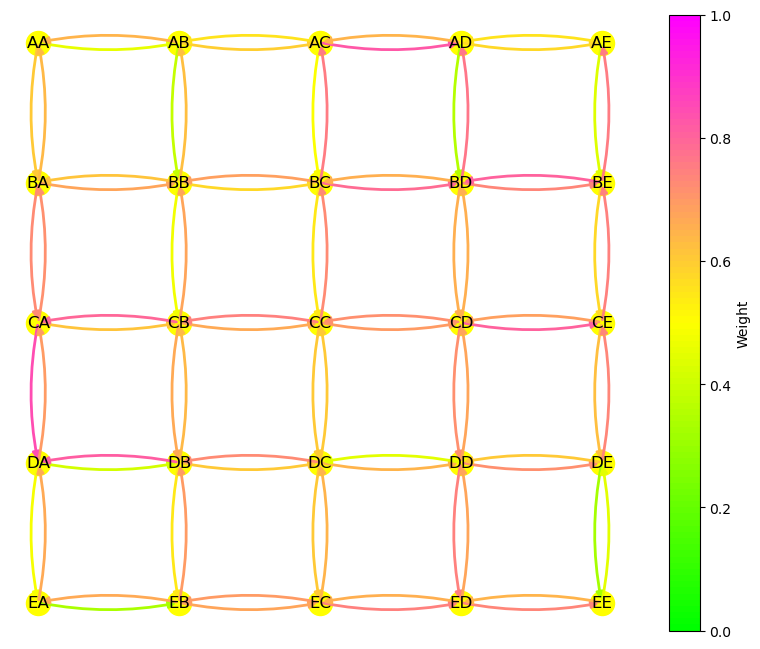

In [30]:
drawCoverNet(G, cover_4)

/tmp/ipykernel_86565/788917706.py:55: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  plt.colorbar(sm, label='Weight')


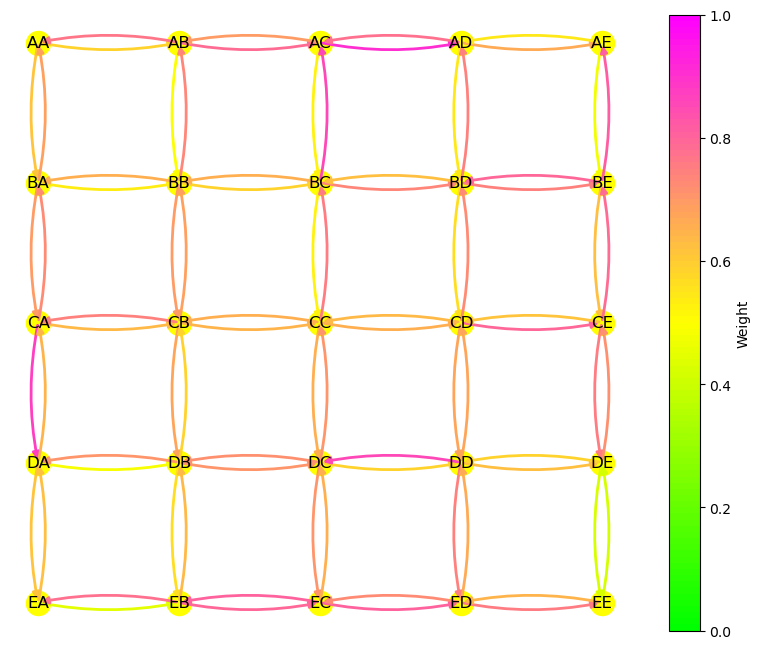

In [31]:
drawCoverNet(G, cover_5)

In [32]:
drawCoverNet(G, cover_6)

NameError: name 'cover_6' is not defined

### 3.3 Draw Network volume

In [ ]:
import numpy as np
import sumolib
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def drawVolumeNet(G, cover_table, net_file='../src/sumo_cfg/toy_net/toy_net1.net.xml'):
    volume_table = np.where(np.sum(cover_table, axis=1) > 0, 1, 0)
    link_volume = np.sum(volume_table, axis=1)
    net = sumolib.net.readNet(net_file)

    # Get node positions from SUMO net file
    pos = {}
    for node in net.getNodes():
        pos[node.getID()] = node.getCoord()

    for i in range(link_volume.shape[0]):
        if i < 60:
            edge_id = 'E' + str(i + 1)
        else:
            edge_id = '-E' + str(i - 59)

        nextNodeID = net.getEdge(edge_id).getToNode().getID()
        lastNodeID = net.getEdge(edge_id).getFromNode().getID()
        G[lastNodeID][nextNodeID]['weight'] = link_volume[i]

    plt.figure(figsize=(8, 8))
    edges, weights = zip(*nx.get_edge_attributes(G, 'weight').items())
    max_weight = max(weights)

    # Create color map for weights
    cmap = plt.get_cmap('RdYlGn_r')  # reversed RdYlGn colormap to get green to red
    norm = mcolors.Normalize(vmin=0, vmax=max_weight)
    colors = [cmap(norm(w)) for w in weights]

    for (src, dst, data), color in zip(G.edges(data=True), colors):
        x0, y0 = pos[src]
        x1, y1 = pos[dst]
        rad = 0.1  # Radius of curvature
        arrowprops=dict(arrowstyle='-|>',
                        color=color,
                        lw=2,  # constant line width
                        connectionstyle=f"arc3,rad={rad}")
        plt.annotate("",
                     xy=(x1, y1),
                     xytext=(x0, y0),
                     arrowprops=arrowprops)

    # Adding colorbar to represent the weight
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    plt.colorbar(sm, label='Weight')

    nx.draw_networkx_nodes(G, pos, node_color='yellow')
    nx.draw_networkx_labels(G, pos)

    plt.axis('off')
    plt.show()


In [ ]:
drawVolumeNet(G, cover_ben)

In [ ]:
drawVolumeNet(G, cover_1)

In [ ]:
drawVolumeNet(G, cover_2)

In [ ]:
drawVolumeNet(G, cover_3)

In [ ]:
drawVolumeNet(G, cover_4)

In [ ]:
drawVolumeNet(G, cover_5)

In [ ]:
drawVolumeNet(G, cover_6)

### 3.5 flexibility

In [ ]:
import json
import matplotlib.pyplot as plt

# Path to your JSON file
json_file_path = "../result/5x5net/flextable/pr2_cover2Flex.json"

# Loading JSON data from the file
with open(json_file_path, 'r') as file:
    data = json.load(file)

# Creating subplots for each CAV. Each subplot will be in one column and multiple rows.
fig, axs = plt.subplots(len(data), 1, figsize=(10, 2 * len(data)))

# Check if there is only one subplot (which would not be in a list)
if len(data) == 1:
    axs = [axs]

# Different markers for variety
markers = 'o'

# Plotting each CAV on a separate subplot with markers
for ax, (cav, attributes) in zip(axs, data.items()):
    flex_values = attributes['Flex']
    ax.plot(flex_values, label=cav, marker=markers)
    ax.set_title(f'CAV {cav} Flex')
    ax.set_ylabel('Flex Value')
    ax.legend()

# Adding a common X label
plt.xlabel('Index')
plt.tight_layout()
plt.show()


